In [143]:
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew
from scipy.signal import find_peaks

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import ruptures as rpt


from sklearn.neighbors import KNeighborsClassifier


## Feature Extraction

In [144]:
def statistical_features(arr):
    vmin = np.amin(arr)
    vmax = np.amax(arr)
    mean = np.mean(arr)
    std = np.std(arr)
    return vmin, vmax, mean, std

def shape_features(arr):
    skewness = skew(arr)
    kurt = kurtosis(arr)
    return skewness, kurt

In [145]:
user = 'DF'

## Pre-processing

In [146]:
import_path = f'{user}'
export_path = f'{user}'

rightEDAdatapath  = f'{import_path}/EDA.csv'
rightHRdatapath   = f'{import_path}/HR.csv'
rightTEMPdatapath = f'{import_path}/TEMP.csv'

In [147]:
rightHRdatapath = np.loadtxt(rightHRdatapath, delimiter = ',')
rightHRdatapath = np.repeat(rightHRdatapath, 4)
np.savetxt('hr_new.csv', rightHRdatapath, delimiter = ',')

In [148]:
edat =  pd.read_csv(f'{user}/EDA.csv',  header = 2,  names = ['EDA'])
hrt =   pd.read_csv(f'hr_new.csv',      header = 12, names = ['HR'])
tempt = pd.read_csv(f'{user}/TEMP.csv', header = 2,  names = ['TEMP'])
gt =    pd.read_csv(f'{user}/EDA.csv',  nrows  = 1)

In [149]:
reference_time = gt.iloc[0,0]
min_len = min(len(edat), len(hrt), len(tempt))

eda = edat.iloc[:min_len, 0]
hrt = hrt.iloc[:min_len, 0]
tempt = tempt.iloc[:min_len, 0]
df_original = pd.concat([eda, hrt, tempt], axis = 1)

In [150]:
array = df_original.values
data = pd.DataFrame(array)
data.columns = ['EDA','HR','temp']

cols = [
    'EDA_Mean','EDA_Min','EDA_Max','EDA_Std', 'EDA_Kurtosis', 'EDA_Skew','EDA_Num_Peaks','EDA_Amphitude','EDA_Duration',
    'HR_Mean','HR_Min','HR_Max','HR_Std','HR_RMS','temp_Mean', 'temp_Min','temp_Max','temp_Std'
]
df_features = pd.DataFrame(columns=cols)

index = 0

for i in range(0,len(data['EDA']), 20):
    df_partial = data.iloc[i:i+40,]
    plen = len(df_partial['EDA'])
    
    if plen < 40:
        continue
    
    eda = df_partial['EDA'].values
    hr = df_partial['HR'].values
    temp = df_partial['temp'].values

    eda_min, eda_max, eda_mean, eda_std = statistical_features(eda)
    hr_min, hr_max, hr_mean, hr_std = statistical_features(hr)
    temp_min, temp_max, temp_mean, temp_std = statistical_features(temp)
    eda_skew, eda_kurtosis = shape_features(eda)
    
    hr_rms = np.sqrt(np.mean(np.square(np.ediff1d(hr))))
    temp_rms= np.sqrt(np.mean(np.square(np.ediff1d(temp))))

    peaks,properties = find_peaks(eda, width=5)
    num_Peaks = len(peaks)
    
    prominences = np.array(properties['prominences'])
    widths = np.array(properties['widths'])
    amphitude = np.sum(prominences)
    duration = np.sum(widths)

    df_features.loc[index] = [eda_mean, eda_min, eda_max, eda_std, eda_kurtosis, eda_skew, num_Peaks, amphitude, duration, hr_mean, hr_min, hr_max, hr_std,hr_rms, temp_mean, temp_min, temp_max, temp_std]

    index = index+1

In [151]:
cols = list(map(str, range(30, 0, -1)))
df_lag_features = pd.DataFrame(columns=cols)
df_lag_features = pd.concat([
    df_features['HR_Mean'].shift(10),  df_features['HR_Mean'].shift(9),    df_features['HR_Mean'].shift(8),
    df_features['HR_Mean'].shift(7),   df_features['HR_Mean'].shift(6),    df_features['HR_Mean'].shift(5),
    df_features['HR_Mean'].shift(4),   df_features['HR_Mean'].shift(3),    df_features['HR_Mean'].shift(2),
    df_features['HR_Mean'].shift(1),   df_features['temp_Mean'].shift(10), df_features['temp_Mean'].shift(9),
    df_features['temp_Mean'].shift(8), df_features['temp_Mean'].shift(7),  df_features['temp_Mean'].shift(6),
    df_features['temp_Mean'].shift(5), df_features['temp_Mean'].shift(4),  df_features['temp_Mean'].shift(3),
    df_features['temp_Mean'].shift(2), df_features['temp_Mean'].shift(1),  df_features['EDA_Mean'].shift(10),
    df_features['EDA_Mean'].shift(9),  df_features['EDA_Mean'].shift(8),   df_features['EDA_Mean'].shift(7),
    df_features['EDA_Mean'].shift(6),  df_features['EDA_Mean'].shift(5),   df_features['EDA_Mean'].shift(4),
    df_features['EDA_Mean'].shift(3),  df_features['EDA_Mean'].shift(2),   df_features['EDA_Mean'].shift(1)], axis=1)
df_lag_features.columns = cols
df_lag_features = df_lag_features.dropna()

In [152]:
df_temp = df_features.iloc[30:3238, 0:31]
df_total = pd.concat([df_lag_features, df_temp], axis=1)

## Stress detection model

In [153]:
df_lag = pd.read_csv('combined_lagEDA.csv')
train_set = df_lag.iloc[:,0:48]
labels = df_lag.iloc[:,48:49]

#Create a random forest Classifier
clf = RandomForestClassifier(n_estimators=100,max_depth=15)

# Split our data
train, test, train_labels, test_labels = train_test_split(train_set, labels, test_size=0.33, random_state=30)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(train, train_labels.values.ravel())

y_pred = clf.predict(test)

f1score   = f1_score        (test_labels, y_pred, average = 'macro')
recall    = recall_score    (test_labels, y_pred, average = 'macro')
precision = precision_score (test_labels, y_pred, average = 'macro')
accuracy  = accuracy_score  (test_labels, y_pred)

print('acc =', accuracy)
print('pre =', precision)
print('recall =', recall) 
print('f1 =', f1score)

acc = 0.9500852203554906
pre = 0.9505654957355629
recall = 0.927118602987466
f1 = 0.9369967120021677


## K-nearest neighbors (KNN)

In [154]:

df_lag = pd.read_csv('combined_lagEDA.csv')
train_set = df_lag.iloc[:,0:48]
labels = df_lag.iloc[:,48:49]

#Create a K-nearest neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=7)

# Split our data
train, test, train_labels, test_labels = train_test_split(train_set, labels, test_size=0.33, random_state=30)

#Train the model using the training sets knn_pred = knn.predict(knn_test)
scaler = MinMaxScaler()
knn_train = scaler.fit_transform(train)
knn_test = scaler.transform(test)
knn.fit(knn_train, train_labels.values.ravel())

knn_pred = knn.predict(knn_test)

f1score_knn   = f1_score        (test_labels, knn_pred , average = 'macro')
recall_knn    = recall_score    (test_labels, knn_pred , average = 'macro')
precision_knn = precision_score (test_labels, knn_pred , average = 'macro')
accuracy_knn  = accuracy_score  (test_labels, knn_pred )

print('acc =', accuracy_knn)
print('pre =', precision_knn)
print('recall =', recall_knn) 
print('f1 =', f1score_knn)

acc = 0.8643778914049184
pre = 0.8413163484355177
recall = 0.835672371096342
f1 = 0.8382198391127827


## Support Vector Machine (SVM)

In [155]:
df_lag = pd.read_csv('combined_lagEDA.csv')
train_set = df_lag.iloc[:,0:48]
labels = df_lag.iloc[:,48:49]

# Create an SVM classifier
svm_model = svm.SVC(kernel='rbf', C=1.0, gamma='scale')

# Split our data
train, test, train_labels, test_labels = train_test_split(train_set, labels, test_size=0.33, random_state=30)

# Scale features for SVM
svm_scaler = MinMaxScaler()
svm_train = svm_scaler.fit_transform(train)
svm_test = svm_scaler.transform(test)

# Train the model
svm_model.fit(svm_train, train_labels.values.ravel())

# Predict and evaluate
svm_pred = svm_model.predict(svm_test)

f1score_svm   = f1_score(test_labels, svm_pred, average='macro')
recall_svm    = recall_score(test_labels, svm_pred, average='macro')
precision_svm = precision_score(test_labels, svm_pred, average='macro')
accuracy_svm  = accuracy_score(test_labels, svm_pred)

print('acc =', accuracy_svm)
print('pre =', precision_svm)
print('recall =', recall_svm)
print('f1 =', f1score_svm)

acc = 0.7173119065010957
pre = 0.7342073244886245
recall = 0.6228464321764259
f1 = 0.6223310961711235


##Predicting SVM

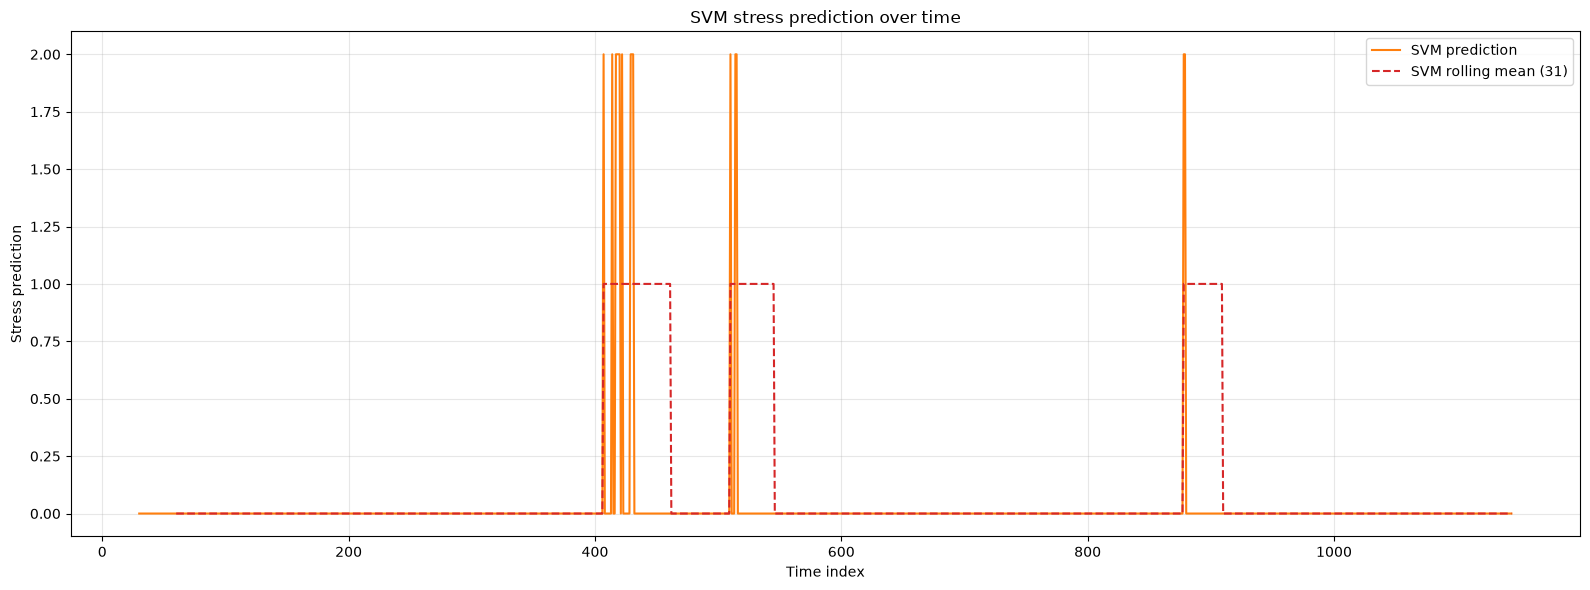

In [156]:
## Predicting SVM

# Prepare the feature matrix for SVM predictions
svm_df_total = df_total.dropna().copy()
svm_scaler = MinMaxScaler()
svm_features = svm_scaler.fit_transform(svm_df_total.iloc[:, 0:48])
svm_features = pd.DataFrame(svm_features)

# Predict using SVM
svm_pred_t = svm_model.predict(svm_features)
svm_pred_t = pd.DataFrame(svm_pred_t, columns=['pred_svm'])

# Save predictions
svm_pred_t.head(30)
svm_pred_t.to_csv('predSVMDF.csv', index=False)

# Add predictions to dataframe
svm_df_total['pred_svm'] = svm_pred_t['pred_svm'].to_numpy()
svm_df_total.to_csv('predSVMDF.csv', index=False)

# Rolling mean for visualization
svm_df_total['MA_3_svm'] = np.ceil(svm_df_total['pred_svm'].rolling(window=31).mean())

# Plot the SVM predictions
plt.figure(figsize=(16, 6))
plt.plot(svm_df_total.index, svm_df_total['pred_svm'], label='SVM prediction', color='tab:orange')
plt.plot(svm_df_total.index, svm_df_total['MA_3_svm'], label='SVM rolling mean (31)', color='tab:red', linestyle='--')
plt.xlabel('Time index')
plt.ylabel('Stress prediction')
plt.title('SVM stress prediction over time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Predicting the stress

In [157]:
df_total = df_total.dropna()
scalar = MinMaxScaler()
x_scaled = scalar.fit_transform(df_total.iloc[:,0:48])
data = pd.DataFrame(x_scaled)
data.fillna(0)

pred_t = clf.predict(data)
pred_t = pd.DataFrame(pred_t)
pred_t.columns=['pred']
pred_t.head(30)
pred_t.to_csv('pred'+user+'.csv')

/workspaces/Stress-Detection-in-Nurses/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [158]:
df_total['pred'] = pred_t['pred'].to_numpy()
df_total.to_csv(f'pred{user}.csv')

In [159]:
df_total['MA_3'] = np.ceil(df_total.iloc[:, 48:49].rolling(window=31).mean())

### Change detection

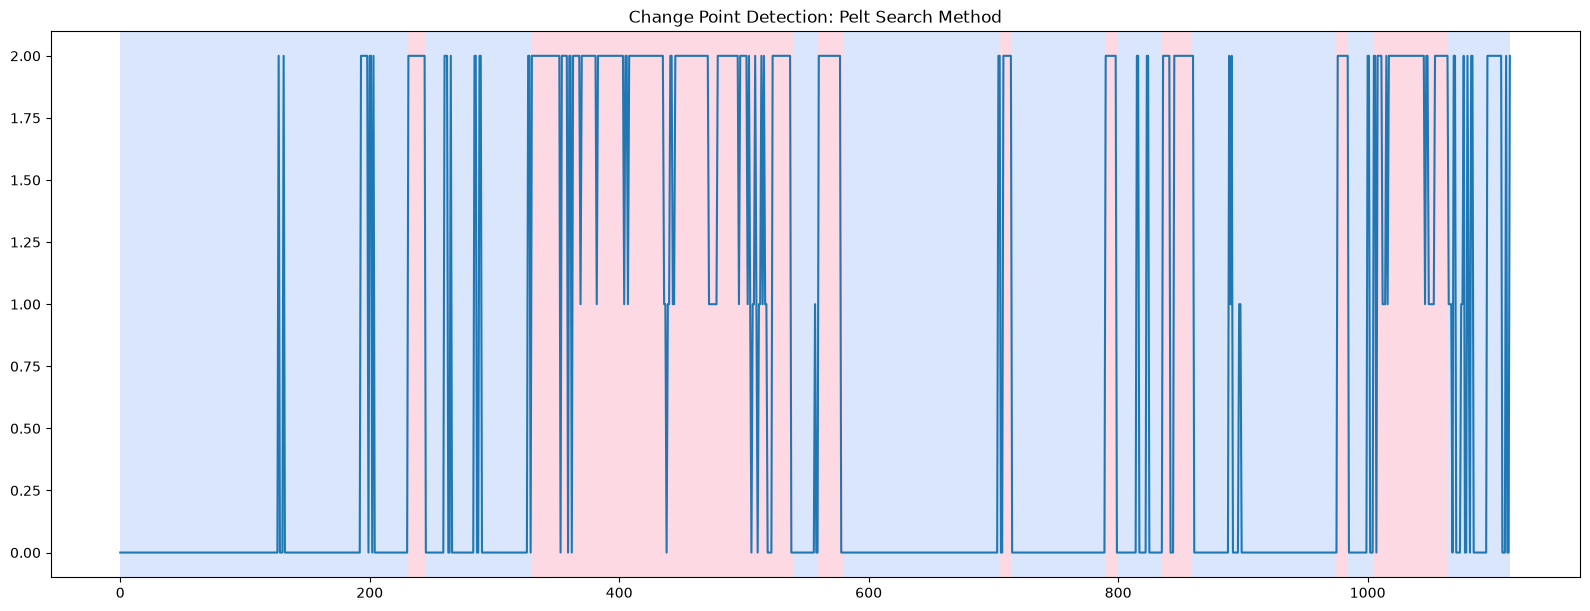

[0, 230, 245, 330, 540, 560, 580, 705, 715, 790, 800, 835, 860, 975, 985, 1005, 1065, 1115]


In [160]:
signal = df_total.iloc[:, 48:49].values.reshape(-1)

algo = rpt.Pelt(model="l2").fit(signal)
result = algo.predict(pen=10)

rpt.display(signal, result, figsize=(16, 6))
plt.title('Change Point Detection: Pelt Search Method')
plt.show()

result = [0] + result
print(result)

### Generating the event by start and end epoch_times

In [161]:
temp_start = 0
temp_end = result[0]

stress = []
for i in range(len(result) - 1):
    segment = df_total.iloc[result[i]:(result[i + 1] - 1), 48:49]
    temp = segment.mean().iloc[0] if not segment.empty else 0.0

    if temp > 1.3:
        temp = 2.0
    elif temp >= 0.65:
        temp = 1
    else:
        temp = 0

    stress.append(temp)


df_temp = pd.DataFrame(columns=['start', 'end', 'stress'])
c = 0
for i in range(len(result) - 1):
    start_point = result[i]
    end_point = result[i + 1]
    stress_value = stress[i]

    if temp_end <= start_point:
        temp_end = end_point
        df_temp.loc[c] = [start_point, end_point, stress_value]
        c += 1


df_temp

,start,end,stress
0,0.0,230.0,0.0
1,230.0,245.0,2.0
2,245.0,330.0,0.0
3,330.0,540.0,2.0
4,540.0,560.0,0.0
5,560.0,580.0,2.0
6,580.0,705.0,0.0
7,705.0,715.0,2.0
8,715.0,790.0,0.0
9,790.0,800.0,2.0


## Change event time to datetime

In [162]:
stress_start = 0
stress_end = 0
tse = 0
previous_stress = -1

for index, row in df_temp.iterrows():

    if row['stress'] == previous_stress:
        stress_end = row['end']
    else:
        if(previous_stress != -1):
            start    = datetime.fromtimestamp(reference_time + (stress_start * 5))
            end      = datetime.fromtimestamp(reference_time + (stress_end * 5))
            timediff = end - start
            print('Prev:', timediff, datetime.fromtimestamp(reference_time + (stress_start * 5)).strftime('%H:%M:%S'), datetime.fromtimestamp(reference_time + (stress_end * 5)).strftime('%H:%M:%S'), previous_stress)
        
        stress_start    = row['start']
        stress_end      = row['end']
        previous_stress = row['stress']
        
print('Final:', timediff, datetime.fromtimestamp(reference_time + (stress_start * 5)).strftime('%H:%M:%S'), datetime.fromtimestamp(reference_time + (stress_end * 5)).strftime('%H:%M:%S'), previous_stress)

Prev: 0:19:10 00:00:04 00:19:14 0.0
Prev: 0:01:15 00:19:14 00:20:29 2.0
Prev: 0:07:05 00:20:29 00:27:34 0.0
Prev: 0:17:30 00:27:34 00:45:04 2.0
Prev: 0:01:40 00:45:04 00:46:44 0.0
Prev: 0:01:40 00:46:44 00:48:24 2.0
Prev: 0:10:25 00:48:24 00:58:49 0.0
Prev: 0:00:50 00:58:49 00:59:39 2.0
Prev: 0:06:15 00:59:39 01:05:54 0.0
Prev: 0:00:50 01:05:54 01:06:44 2.0
Prev: 0:02:55 01:06:44 01:09:39 0.0
Prev: 0:02:05 01:09:39 01:11:44 2.0
Prev: 0:09:35 01:11:44 01:21:19 0.0
Prev: 0:00:50 01:21:19 01:22:09 2.0
Prev: 0:01:40 01:22:09 01:23:49 0.0
Prev: 0:05:00 01:23:49 01:28:49 2.0
Final: 0:05:00 01:28:49 01:32:59 1.0
